In [21]:
import pandas as pd
import os
import sys

sys.path.append("..")

os.makedirs("../reports/figures", exist_ok=True)
from src.nettoyage import convertir_montant, convertir_salaire, extraire_postes, extraire_matchs

In [22]:
df_tech = pd.read_csv("../data/raw/Attribut_technique.csv")
df_mental = pd.read_csv("../data/raw/Attribut_mental.csv")
df_general = pd.read_csv("../data/raw/info_general.csv")

In [23]:
df_tech.head()

,Unnamed: 0,Joueur,Corners,Centres,Finition,Contrôle de balle,Coups francs,Jeu de tête,Tirs de loin,Touches longues,Passes,Penalty,Tacles,Technique
0,NaN,Josh Street,3,3,1,8,5,2,3,1,13,4,2,13
1,NaN,Achraf Hakimi,7,15,13,16,13,11,13,11,16,10,13,14
2,NaN,Leny Yoro,5,6,7,14,4,16,9,5,14,10,14,14
3,NaN,Matthijs de Ligt,4,6,8,12,8,16,10,8,13,8,16,12
4,NaN,Alejandro Grimaldo,17,16,11,17,18,7,15,12,16,14,11,17


In [24]:
df_mental.head()

,Unnamed: 0,Joueur,Agressivité,Anticipation,Courage,Sang-froid,Concentration,Décisions,Appels de balle,Placement,Travail d'équipe,Vision du jeu,Volume de jeu
0,NaN,Josh Street,13,14,12,12,16,17,3,16,9,16,10
1,NaN,Achraf Hakimi,15,13,12,13,13,13,17,13,13,13,14
2,NaN,Leny Yoro,12,16,14,15,16,15,11,16,12,14,13
3,NaN,Matthijs de Ligt,16,15,18,12,15,14,7,16,15,10,15
4,NaN,Alejandro Grimaldo,12,16,12,17,14,15,15,11,14,15,15


In [25]:
df_tech = df_tech.drop(columns=["Unnamed: 0"])
df_mental = df_mental.drop(columns=["Unnamed: 0"])
df_general = df_general.drop(columns=["Unnamed: 0"])

In [26]:
df_general = df_general.drop(columns=["Niveau", "Potentiel", "Forme", "Con. Condition physique d'ensemble", "Fph Forme physique", "Mor"])

In [27]:
df = pd.merge(df_tech, df_mental, on="Joueur")
df = pd.merge(df, df_general, on="Joueur")

In [28]:
print(df.shape)
df.head()

(34, 37)


,Joueur,Corners,Centres,Finition,Contrôle de balle,Coups francs,Jeu de tête,Tirs de loin,Touches longues,Passes,...,Meilleur pied,Matchs disputés,Buts,Passes décisives,Note,Satisfaction temps de jeu,Âge,Expire le,Salaire,Montant transfert
0,Josh Street,3,3,1,8,5,2,3,1,13,...,Droitier,19,0,0,"7,08",Ravi,18,30/6/2031,160K € p/m,39M € - 45M €
1,Achraf Hakimi,7,15,13,16,13,11,13,11,16,...,Droitier,33 (2),5,13,"7,50",Satisfait,30,30/6/2031,"1,6M € p/m",241M € - 289M €
2,Leny Yoro,5,6,7,14,4,16,9,5,14,...,Droitier,40,3,1,"7,07",Ravi,23,30/6/2030,567K € p/m,88M € - 97M €
3,Matthijs de Ligt,4,6,8,12,8,16,10,8,13,...,Droitier,37 (2),4,3,"7,19",Très heureux,29,30/6/2030,"1,1M € p/m",68M € - 75M €
4,Alejandro Grimaldo,17,16,11,17,18,7,15,12,16,...,Gaucher,33 (7),2,6,"6,87",Satisfait,33,30/6/2030,900K € p/m,"12M € - 14,5M €"


In [29]:
df.to_csv("../data/processed/fm26_data_clean.csv", index=False)

In [30]:
df["Matchs disputés"].unique()

<StringArray>
[     '19',  '33 (2)',      '40',  '37 (2)',  '33 (7)',   '5 (2)',  '28 (7)',
  '32 (5)', '20 (21)',   '8 (3)', '25 (13)',      '25',  '28 (4)', '20 (19)',
   '3 (3)', '16 (14)',   '4 (4)',   '3 (5)',  '6 (20)',  '8 (16)',       '5',
   '2 (4)',   '6 (5)',   '4 (2)',       '4',      '37',  '29 (4)',  '39 (1)',
  '28 (5)',   '3 (2)',   '1 (4)',  '2 (10)']
Length: 32, dtype: str

In [31]:
df["Matchs disputés"].dtype

<StringDtype(storage='python', na_value=nan)>

In [32]:
df["Titularisations"] = df["Matchs disputés"].str.extract(r"(\d+)").astype(int)
df["Remplacements"] = df["Matchs disputés"].str.extract(r"\((\d+)\)").fillna(0).astype(int)

In [33]:
df[["Matchs disputés", "Titularisations", "Remplacements"]].head(10)

,Matchs disputés,Titularisations,Remplacements
0,19,19,0
1,33 (2),33,2
2,40,40,0
3,37 (2),37,2
4,33 (7),33,7
5,5 (2),5,2
6,28 (7),28,7
7,32 (5),32,5
8,20 (21),20,21
9,8 (3),8,3


In [34]:
df["Salaire"].unique()

<StringArray>
[  '160K € p/m',   '1,6M € p/m',   '567K € p/m',   '1,1M € p/m',
   '900K € p/m',  '1,27M € p/m',   '799K € p/m',     '1M € p/m',
  '1,31M € p/m',  '2,38M € p/m',   '1,3M € p/m',   '301K € p/m',
  '1,25M € p/m',  '1,93M € p/m',   '602K € p/m',   '803K € p/m',
  '40,5K € p/m',   '621K € p/m',   '750K € p/m',   '147K € p/m',
 '16,25K € p/m',  '81,5K € p/m',   '825K € p/m',    '52K € p/m',
   '133K € p/m',  '24,5K € p/m',    '30K € p/m',  '1,92M € p/m',
  '69,5K € p/m',  '1,23M € p/m',   '2,4M € p/m',    '50K € p/m',
   '156K € p/m']
Length: 33, dtype: str

In [35]:
extrait = df["Salaire"].str.extract(r"([\d,]+)(K|M)")
extrait.columns = ["valeur", "unite"]
extrait.head(10)

,valeur,unite
0,160,K
1,"1,6",M
2,567,K
3,"1,1",M
4,900,K
5,"1,27",M
6,799,K
7,1,M
8,"1,31",M
9,"2,38",M


In [36]:
extrait["valeur"] = extrait["valeur"].str.replace(",", ".").astype(float)

In [37]:
multiplicateur = extrait["unite"].map({"K": 1_000, "M": 1_000_000})
df["Salaire (€/mois)"] = extrait["valeur"] * multiplicateur

In [38]:
df[["Salaire", "Salaire (€/mois)"]].head(10)

,Salaire,Salaire (€/mois)
0,160K € p/m,160000.0
1,"1,6M € p/m",1600000.0
2,567K € p/m,567000.0
3,"1,1M € p/m",1100000.0
4,900K € p/m,900000.0
5,"1,27M € p/m",1270000.0
6,799K € p/m,799000.0
7,1M € p/m,1000000.0
8,"1,31M € p/m",1310000.0
9,"2,38M € p/m",2380000.0


In [39]:
print(df["Montant transfert"].unique().tolist())

['39M\xa0€ - 45M\xa0€', '241M\xa0€ - 289M\xa0€', '88M\xa0€ - 97M\xa0€', '68M\xa0€ - 75M\xa0€', '12M\xa0€ - 14,5M\xa0€', 'Pas à vendre', '92M\xa0€ - 101M\xa0€', '10M\xa0€ - 11M\xa0€', '152M\xa0€ - 167M\xa0€', '70M\xa0€', '14M\xa0€ - 17M\xa0€', '53M\xa0€ - 65M\xa0€', '212M\xa0€ - 254M\xa0€', '9,6M\xa0€ - 11,5M\xa0€', '124M\xa0€ - 135M\xa0€', '16M\xa0€', '6M\xa0€ - 6,6M\xa0€', '33,5M\xa0€', '6,6M\xa0€ - 7,8M\xa0€', '100K\xa0€ - 250K\xa0€', '15,5M\xa0€ - 23M\xa0€', '17M\xa0€ - 18,5M\xa0€', '160K\xa0€ - 475K\xa0€', '16M\xa0€ - 20M\xa0€', '95K\xa0€ - 400K\xa0€', '95K\xa0€ - 325K\xa0€', '130M\xa0€ - 143M\xa0€', '18,5M\xa0€ - 23M\xa0€', '120M\xa0€ - 131M\xa0€', '110M\xa0€', '475K\xa0€ - 1M\xa0€', '21M\xa0€ - 25M\xa0€']


In [40]:
df[["Montant transfert min", "Montant transfert max"]] = df["Montant transfert"].apply(
    lambda x: pd.Series(convertir_montant(x))
)

In [41]:
df[["Montant transfert", "Montant transfert min", "Montant transfert max"]].head(10)

,Montant transfert,Montant transfert min,Montant transfert max
0,39M € - 45M €,39000000.0,45000000.0
1,241M € - 289M €,241000000.0,289000000.0
2,88M € - 97M €,88000000.0,97000000.0
3,68M € - 75M €,68000000.0,75000000.0
4,"12M € - 14,5M €",12000000.0,14500000.0
5,Pas à vendre,NaN,NaN
6,92M € - 101M €,92000000.0,101000000.0
7,10M € - 11M €,10000000.0,11000000.0
8,152M € - 167M €,152000000.0,167000000.0
9,Pas à vendre,NaN,NaN


In [42]:
df["Note"] = df["Note"].str.replace(",", ".").astype(float)

In [43]:
df["Note"].head(10)
df["Note"].dtype

dtype('float64')

In [44]:
df["Note"].head(10)

0    7.08
1    7.50
2    7.07
3    7.19
4    6.87
5    6.80
6    7.10
7    7.20
8    6.92
9    7.80
Name: Note, dtype: float64

In [45]:
df["Expire le"] = pd.to_datetime(df["Expire le"], format="%d/%m/%Y")

In [46]:
date_save = pd.Timestamp("2029-03-17")
df["Années restantes contrat"] = (df["Expire le"] - date_save).dt.days / 365.25

In [47]:
df[["Expire le", "Années restantes contrat"]].head(10)

,Expire le,Années restantes contrat
0,2031-06-30,2.286105
1,2031-06-30,2.286105
2,2030-06-30,1.286790
3,2030-06-30,1.286790
4,2030-06-30,1.286790
5,2033-06-30,4.287474
6,2033-06-30,4.287474
7,2030-06-30,1.286790
8,2032-06-30,3.288159
9,2031-06-30,2.286105


In [48]:
print(extraire_postes("M (C), MO (DGC), BT (C)"))
print(extraire_postes("D/AL/M (D)"))

['M', 'BT', 'MO']
['D', 'M', 'AL']


In [49]:
df["Postes possibles"] = df["Position"].apply(extraire_postes)

In [50]:
df[["Position", "Postes possibles"]].head(10)

,Position,Postes possibles
0,GB,[GB]
1,D/AL/M (D),"[D, M, AL]"
2,D (C),[D]
3,"D (C), MD","[D, MD]"
4,"D/AL (G), MD, M/MO (G)","[MD, D, M, MO, AL]"
5,"MD, M (C)","[M, MD]"
6,"MD, M/MO (C)","[M, MD, MO]"
7,"MD, M/MO (C)","[M, MD, MO]"
8,"M (C), MO (DGC), BT (C)","[M, BT, MO]"
9,"MO (DG), BT (C)","[MO, BT]"


In [51]:
#Bon la on converti la liste de poste en string pour avoir un CSV propre
df["Postes possibles"] = df["Postes possibles"].apply(lambda x: "/".join(x))

#la je supprime les anciennes colonnes pour remplacer avec les version nettoyées
colonnes_a_supprimer = [
    "Matchs disputés",
    "Salaire",
    "Montant transfert",
    "Position",
]
df_final = df.drop(columns=colonnes_a_supprimer)

#petite verification avant l'export
print(df_final.shape)
print(df_final.dtypes)
df_final.head()

#la sauvegarde
df_final.to_csv("../data/processed/fm26_data_clean.csv", index=False)

(34, 40)
Joueur                                  str
Corners                               int64
Centres                               int64
Finition                              int64
Contrôle de balle                     int64
Coups francs                          int64
Jeu de tête                           int64
Tirs de loin                          int64
Touches longues                       int64
Passes                                int64
Penalty                               int64
Tacles                                int64
Technique                             int64
Agressivité                           int64
Anticipation                          int64
Courage                               int64
Sang-froid                            int64
Concentration                         int64
Décisions                             int64
Appels de balle                       int64
Placement                             int64
Travail d'équipe                      int64
Vision du jeu          

In [52]:
df = pd.read_csv("../data/processed/fm26_data_clean.csv")
df.shape

(34, 40)

In [53]:
df.describe()

,Corners,Centres,Finition,Contrôle de balle,Coups francs,Jeu de tête,Tirs de loin,Touches longues,Passes,Penalty,...,Buts,Passes décisives,Note,Âge,Titularisations,Remplacements,Salaire (€/mois),Montant transfert min,Montant transfert max,Années restantes contrat
count,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,...,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,3.400000e+01,3.100000e+01,3.100000e+01,34.000000
mean,8.117647,10.088235,9.558824,13.941176,8.470588,9.911765,9.470588,5.676471,13.735294,9.058824,...,3.382353,3.058824,7.008235,25.382353,16.558824,5.411765,7.917132e+05,5.469758e+07,6.167258e+07,2.228127
std,4.649957,4.467849,4.370640,2.673565,5.010506,4.216617,4.201265,3.723151,2.987944,4.545668,...,4.532808,3.797457,0.237480,4.658096,13.464186,6.140366,7.007431e+05,6.475059e+07,7.460993e+07,1.347238
min,1.000000,2.000000,1.000000,8.000000,1.000000,2.000000,1.000000,1.000000,7.000000,2.000000,...,0.000000,0.000000,6.540000,18.000000,1.000000,0.000000,1.625000e+04,9.500000e+04,2.500000e+05,0.287474
25%,4.000000,7.000000,7.000000,12.250000,4.000000,6.000000,6.250000,3.000000,13.000000,5.250000,...,0.000000,0.000000,6.870000,22.000000,4.250000,1.250000,1.365000e+05,9.800000e+06,1.125000e+07,1.286790
50%,7.500000,11.000000,9.000000,14.000000,7.000000,11.000000,11.000000,5.000000,14.000000,9.000000,...,1.000000,2.000000,7.000000,24.000000,12.000000,4.000000,7.745000e+05,1.850000e+07,2.300000e+07,2.286105
75%,12.750000,13.000000,13.000000,16.000000,13.000000,13.000000,12.000000,7.750000,15.750000,12.000000,...,5.000000,4.750000,7.095000,30.000000,28.000000,6.500000,1.245000e+06,9.000000e+07,9.900000e+07,3.288159
max,17.000000,16.000000,19.000000,18.000000,18.000000,16.000000,15.000000,17.000000,19.000000,19.000000,...,16.000000,14.000000,7.800000,34.000000,40.000000,21.000000,2.400000e+06,2.410000e+08,2.890000e+08,4.287474


In [54]:
df.sort_values("Note", ascending=False) [["Joueur", "Note", "Postes possibles"]].head(10)

,Joueur,Note,Postes possibles
9,Kylian Mbappé,7.80,MO/BT
1,Achraf Hakimi,7.50,D/M/AL
33,Eli Junior Kroupi,7.38,BT
10,Marcus Rashford,7.23,M/BT/MO
7,Bruno Fernandes,7.20,M/MD/MO
3,Matthijs de Ligt,7.19,D/MD
17,Bendito Mantato,7.14,BT/D/M/MO/AL
30,Endrick,7.11,MO/BT
6,Lucas Bergvall,7.10,M/MD/MO
0,Josh Street,7.08,GB


In [55]:
df["Poste principal"] = df["Postes possibles"].str.split("/").str[0]
df.groupby("Poste principal")["Note"].mean().sort_values(ascending=False)

Poste principal
MO    7.270000
BT    7.180000
M     6.997273
D     6.972500
MD    6.870000
GB    6.855000
Name: Note, dtype: float64

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
df = pd.read_csv("../data/processed/fm26_data_clean.csv")
df["Poste principal"] = df["Postes possibles"].str.split("/").str[0]

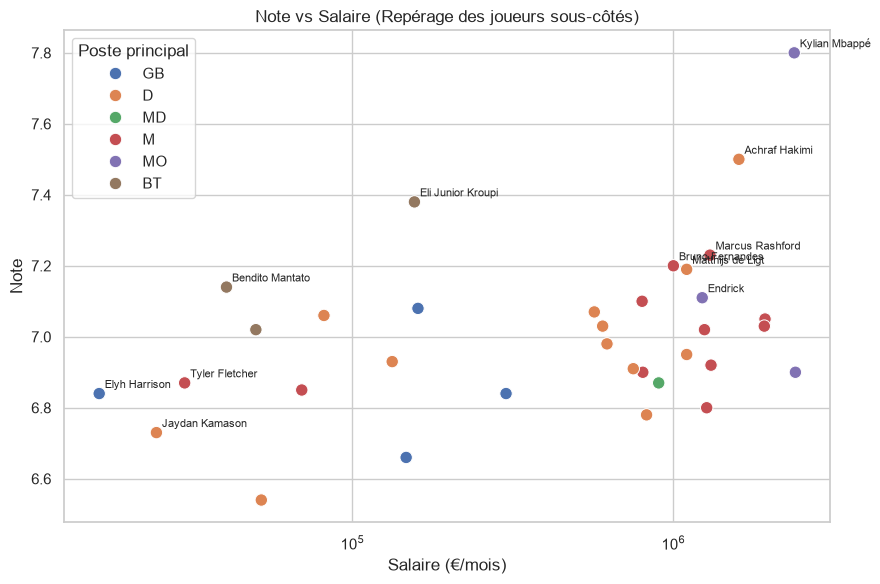

In [57]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(data=df, x="Salaire (€/mois)", y="Note", hue="Poste principal", s=80, ax=ax)
ax.set_xscale("log")
ax.set_title("Note vs Salaire (Repérage des joueurs sous-côtés)")
for _, row in df.iterrows():
    if row["Note"] > 7.1 or row["Salaire (€/mois)"] < 50000:
        ax.annotate(row["Joueur"], (row["Salaire (€/mois)"], row["Note"]),
                    fontsize=8, xytext=(4, 4), textcoords="offset points")
plt.tight_layout()
plt.savefig("../reports/figures/note_vs_salaire.png", dpi=150, bbox_inches="tight")
plt.show()

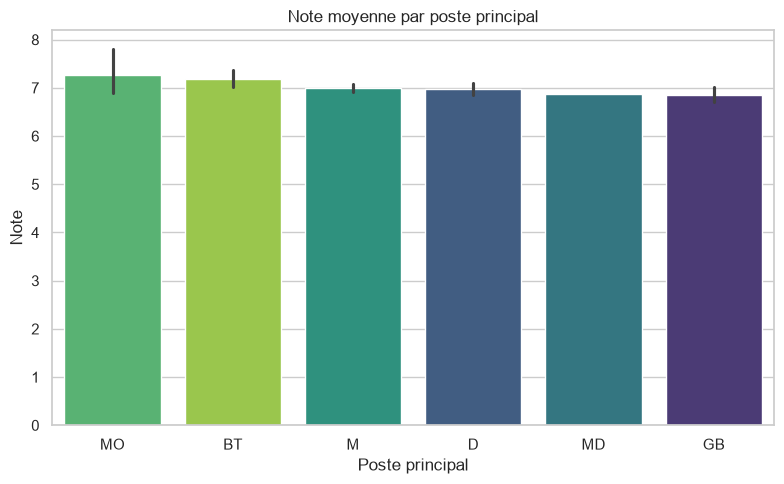

In [58]:
fig, ax = plt.subplots(figsize=(8, 5))
order = df.groupby("Poste principal")["Note"].mean().sort_values(ascending=False).index
sns.barplot(data=df, x="Poste principal", y="Note", hue ="Poste principal",
            order = order, palette="viridis", legend=False, ax=ax)
ax.set_title("Note moyenne par poste principal")
plt.tight_layout()
plt.savefig("../reports/figures/note_par_poste.png", dpi=150, bbox_inches="tight")
plt.show()

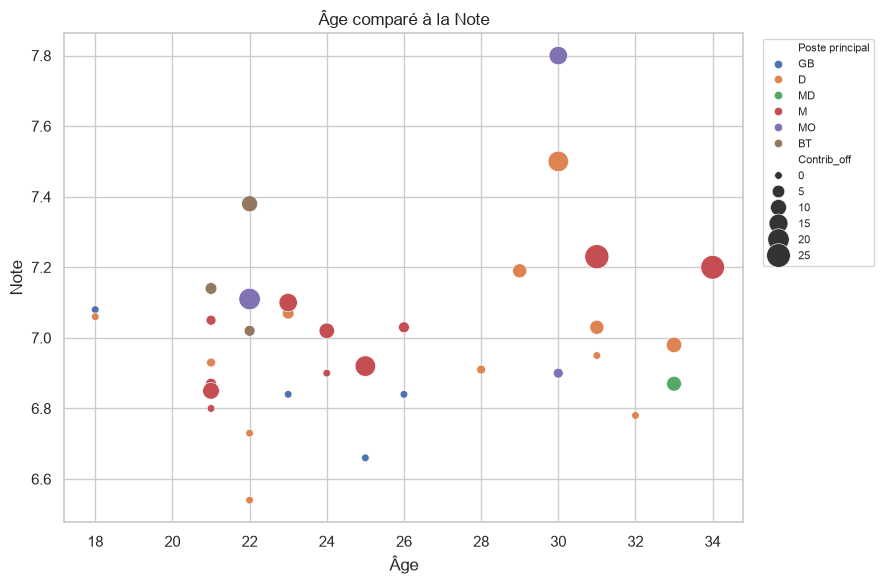

In [59]:
df["Contrib_off"] = df["Buts"] + df["Passes décisives"]
fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(data=df, x="Âge", y="Note", size="Contrib_off",
                hue = "Poste principal", sizes = (30, 300), ax=ax)
ax.set_title("Âge comparé à la Note")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig("../reports/figures/age_vs_note.png", dpi=150, bbox_inches="tight")
plt.show()

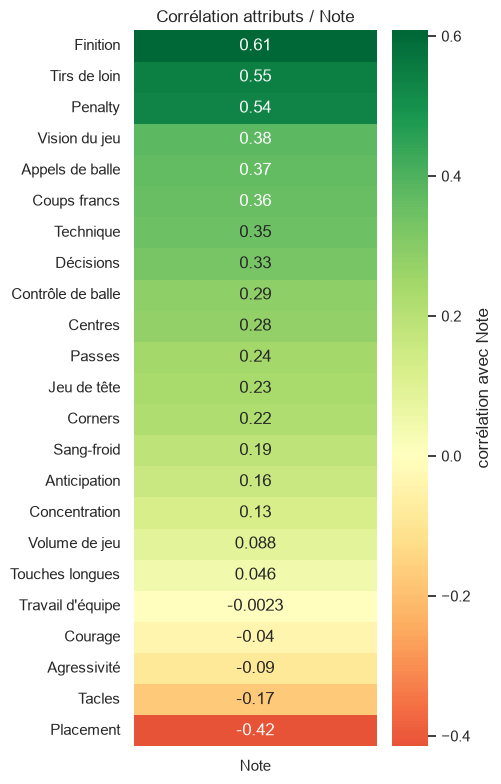

In [60]:
attrs = ["Corners", "Centres", "Finition", "Contrôle de balle", "Coups francs",
         "Jeu de tête", "Tirs de loin", "Touches longues", "Passes", "Penalty",
         "Tacles", "Technique", "Agressivité", "Anticipation", "Courage",
         "Sang-froid", "Concentration", "Décisions", "Appels de balle",
         "Placement", "Travail d'équipe", "Vision du jeu", "Volume de jeu", "Note"]
corr = df[attrs].corr()[["Note"]].drop("Note").sort_values("Note", ascending=False)
fig, ax = plt.subplots(figsize=(5, 8))
sns.heatmap(corr, annot=True, cmap="RdYlGn", center=0, ax=ax,
            cbar_kws={"label": "corrélation avec Note"})
ax.set_title("Corrélation attributs / Note")
plt.tight_layout()
plt.savefig("../reports/figures/correlation_attrs.png.png", dpi=150, bbox_inches="tight")
plt.show()